# UQ Failure Analysis Larger Model
---

## Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from scipy.spatial import cKDTree

from reionemu import (
    load_training_arrays,
    MCDropoutEmulator,
    predict_mc,
)

## Paths and Constants

In [2]:
h5_path = "../data/condensed_v6.h5"
fig_path = "../results/figures/larger_model/"

# Larger Model
ckpt_path = "../checkpoints/larger_model/checkpoint.pt"
norm_path = "../checkpoints/larger_model/norm/"
split_idx_path = "../checkpoints/larger_model/split_idx/split_idx.npz"

In [3]:
SEED = 42

param_names = ["zmean_zre", "alpha_zre", "kb_zre", "b0_zre"]

modelcfg = {
    "input_dim": 4,
    "output_dim": 5,
    "hidden_dim": 32,
    "num_hidden_layers": 3,
    "activation": "relu",
    "dropout_rate": 0.1,
}

## Load Data

In [4]:
X, Y, ell = load_training_arrays(h5_path)

X_mean = np.load(norm_path + "X_mean.npy")
X_std = np.load(norm_path + "X_std.npy")

splits_idx = np.load(split_idx_path)
test_idx = splits_idx["test_idx"]
X_test = X[test_idx]
Y_test = Y[test_idx]

train_idx = splits_idx["train_idx"]
X_train = X[train_idx]
Y_train = Y[train_idx]

X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

zmean = X[:,0]
alpha = X[:,1]
k0 = X[:,2]
b0 = X[:,3]

print(f"{len(test_idx)} Test Split Global Indices:\n{test_idx}")

200 Test Split Global Indices:
[560 481 499 323  93 843 877 763 389 397 564  32 386 364 667 453 440 640
 633 227 369 642 416 452  81 827 820 863 370 311 450  52 912 342 540 267
 721 106 122 396 992 533 730 384 105 266 347 190 864 850  39 339 188 403
 525 189 812  87 732 483   5 597 699 953 442 893 861 385 332 790 359 590
 504 962 375 114 170 851 123 301 615 602 711 786 918 508 718 599 221 654
 111 475 484 329 279 277 349 956 187  65 974 611 583 948  69 410 689 637
 177 736 982 117 586 372  10 628 927 669  63 735 500   1  42 634 529 167
 809 821  76 313 296 502 490 720 837 543 641 939 617 290 779 910 212 555
 967 672 317  57 791 535 932 272  15 432 503 828 621 137 702 287 451 528
 300 752 622 943 195  34 286 314 970 547 333 182  49 518 102 687 651  41
 553 366 534 275 675 832 303 113 749 908 437 491 526 141 706 548 609 961
 973 648]


# Larger Model Analysis
---

## Load Model

In [5]:
state_dict = torch.load(ckpt_path, weights_only=False)

model = MCDropoutEmulator(**modelcfg)
model.load_state_dict(state_dict)

model.eval()

MCDropoutEmulator(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=32, out_features=5, bias=True)
  )
)

## Make Predictions

In [6]:
np.random.seed(SEED)
torch.manual_seed(SEED)

pred_mean, pred_std, _, _ = predict_mc(X_test, model, X_mean, X_std, n_mc_samples=201, device="cpu")

# Accuracy
---

In [7]:
rel_error = np.abs(pred_mean - np.exp(Y_test)) / np.exp(Y_test)
rel_std = pred_std / pred_mean
sim_mean_rel_error = np.mean(np.abs(pred_mean - np.exp(Y_test)) / np.exp(Y_test), axis=1)
sim_mean_rel_std = (pred_std / pred_mean).mean(axis=1)

print(f"Mean Relative Error: {rel_error.mean()}")

Mean Relative Error: 0.051160115748643875


# Error and Uncertainty Against Each Input Parameter
---

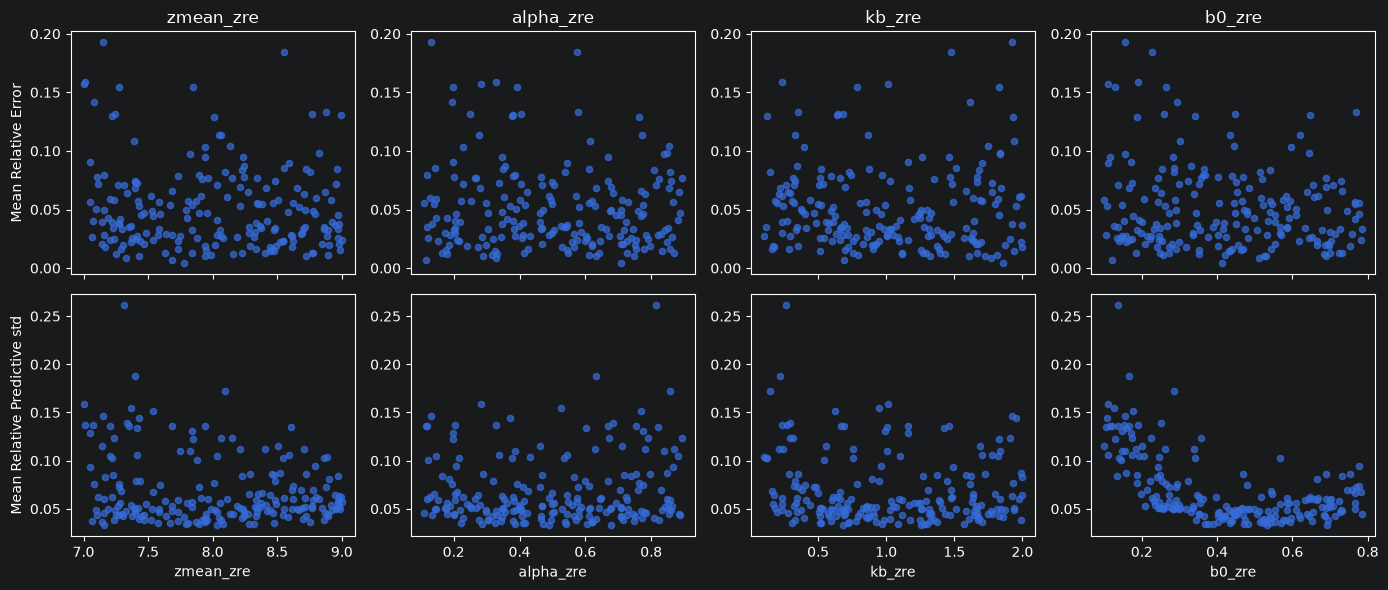

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex="col")

for col in range(4):
    # Relative Error
    axes[0, col].scatter(X_test[:, col], sim_mean_rel_error, s=20, alpha=0.7)
    axes[0, col].set_title(param_names[col])

    # Predictive Uncertainty
    axes[1, col].scatter(X_test[:, col], sim_mean_rel_std, s=20, alpha=0.7)
    axes[1, col].set_xlabel(param_names[col])

axes[0, 0].set_ylabel("Mean Relative Error")
axes[1, 0].set_ylabel("Mean Relative Predictive std")

plt.tight_layout()
plt.savefig(fig_path + "error-uncertainty-vs-param", dpi=150, bbox_inches="tight")
plt.show()

# Correlation Between $\sigma$ and Error
---

In [9]:
res_s, pvalue_s = spearmanr(sim_mean_rel_std, sim_mean_rel_error)
res_p, pvalue_p = pearsonr(sim_mean_rel_std, sim_mean_rel_error)

print(f"Spearman Correlation:\t{res_s:.3f}, p-value: {pvalue_s:.3f}")
print(f"Pearson Correlation:\t{res_p:.3f}, p-value: {pvalue_p:.3f}")

Spearman Correlation:	0.076, p-value: 0.286
Pearson Correlation:	0.172, p-value: 0.015


# Correlation Between Nearest Neighbors and  Error
---

Spearman:	0.192, p-value: 0.00658
Pearson:	0.149, p-value: 0.0356


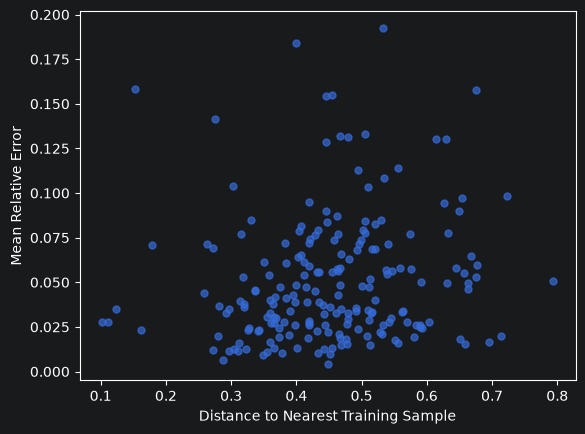

In [10]:
tree = cKDTree(X_train_norm)
nearest_dist, nearest_train_pos = tree.query(X_test_norm, k=1)
nearest_global_idx = train_idx[nearest_train_pos]

rho_s, p_s = spearmanr(nearest_dist, sim_mean_rel_error)
rho_p, p_p = pearsonr(nearest_dist, sim_mean_rel_error)

print(f"Spearman:\t{rho_s:.3f}, p-value: {p_s:.3g}")
print(f"Pearson:\t{rho_p:.3f}, p-value: {p_p:.3g}")

plt.scatter(nearest_dist, sim_mean_rel_error, s=25, alpha=0.7)
plt.xlabel("Distance to Nearest Training Sample")
plt.ylabel("Mean Relative Error")
plt.savefig(fig_path+'distance-vs-error', dpi=150, bbox_inches='tight')
plt.show()

# Correlation Between Nearest Neighbors and $\sigma$
---

Spearman:	-0.115, p-value: 0.105
Pearson:	-0.129, p-value: 0.0693


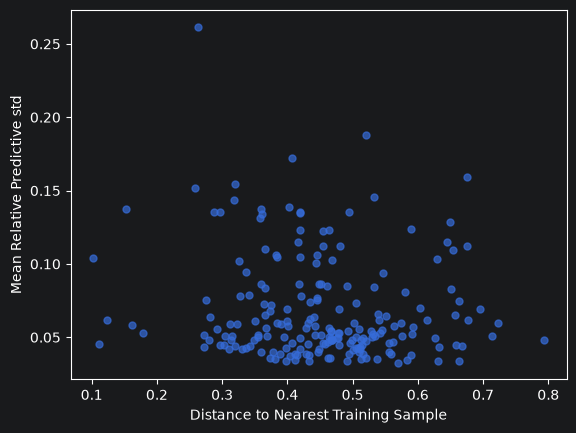

In [11]:
tree = cKDTree(X_train_norm)
nearest_dist, nearest_train_pos = tree.query(X_test_norm, k=1)
nearest_global_idx = train_idx[nearest_train_pos]

rho_s, p_s = spearmanr(nearest_dist, sim_mean_rel_std)
rho_p, p_p = pearsonr(nearest_dist, sim_mean_rel_std)

print(f"Spearman:\t{rho_s:.3f}, p-value: {p_s:.3g}")
print(f"Pearson:\t{rho_p:.3f}, p-value: {p_p:.3g}")

plt.scatter(nearest_dist, sim_mean_rel_std, s=25, alpha=0.7)
plt.xlabel("Distance to Nearest Training Sample")
plt.ylabel("Mean Relative Predictive std")
plt.savefig(fig_path+'distance-vs-uncertainty', dpi=150, bbox_inches='tight')
plt.show()

# Inspect Overconfident Cases
---

## Compute Pulls

In [12]:
pulls = (pred_mean - np.exp(Y_test)) / pred_std
abs_pulls = np.abs(pred_mean - np.exp(Y_test)) / pred_std

mean_abs_pulls = np.mean(abs_pulls, axis=1)
mean_abs_pulls_idx = np.argsort(mean_abs_pulls)[::-1]

print(mean_abs_pulls_idx)

[ 50 171 149  86 137  11  24  40 169 174 105 161 193  80  12 168 132  58
 181 131 185  92 114 147  59 122 103 172 156  83  18  49  29 130  96 108
 165 153  37  69 197  87  34  45  22  10 151  91 182  98  43 123 158  32
 135  36  82   5 191 159 144 112  17  46 138  30 125  13 116  27  93  47
  65 129 157  94  16 184 162   0  72 179  60   2 199 109 177  52 148 195
 194 170   8 190   9 107  75 192  81 163  39  79  64 128  23 154  28 150
  21  99 180  48 146 173  88  89 134  57 101 102   1 126 140  90 186 113
  73  76  85  78  53  95  38 155 110  68 100 175 183  54  63 167 136  61
 152 142   6  77 166  62 141   3  35 133  71  74  26  67 198  51   4  70
 139 117 124  14 120  66 178 143 121  44 145 106  41 111  31  15 189  84
  42 118 160 119  55   7  19  56 104 127  20 188  25 176 115 164  97  33
 187 196]


In [13]:
for i in range(3):
    idx = mean_abs_pulls_idx[i]
    print(f"Simulation {idx}")
    print(f"\tParameters: {X_test[idx]}")
    print(f"\tPulls: {pulls[idx]}")
    print(f"\t|Pulls|: {abs_pulls[idx]}")
    print(f"\tMean |Pull|: {mean_abs_pulls[idx]}")
    print(f"\tMean Relative Error: {sim_mean_rel_error[idx]}")

Simulation 50
	Parameters: [8.555149  0.5734222 1.4763184 0.2265809]
	Pulls: [-4.788975  -4.826419  -3.993214  -3.072829  -2.4550946]
	|Pulls|: [4.788975  4.826419  3.993214  3.072829  2.4550946]
	Mean |Pull|: 3.8273062705993652
	Mean Relative Error: 0.18409554660320282
Simulation 171
	Parameters: [7.9380045  0.22767743 0.39409345 0.59501696]
	Pulls: [-6.165448  -3.3759472 -2.3590775 -1.9052329 -1.9693322]
	|Pulls|: [6.165448  3.3759472 2.3590775 1.9052329 1.9693322]
	Mean |Pull|: 3.1550076007843018
	Mean Relative Error: 0.10342814773321152
Simulation 149
	Parameters: [8.77111    0.24975798 0.64475316 0.25997373]
	Pulls: [-3.875753  -3.4990385 -3.0125332 -2.2489815 -1.9425187]
	|Pulls|: [3.875753  3.4990385 3.0125332 2.2489815 1.9425187]
	Mean |Pull|: 2.9157650470733643
	Mean Relative Error: 0.1314634382724762


## Most Overconfident

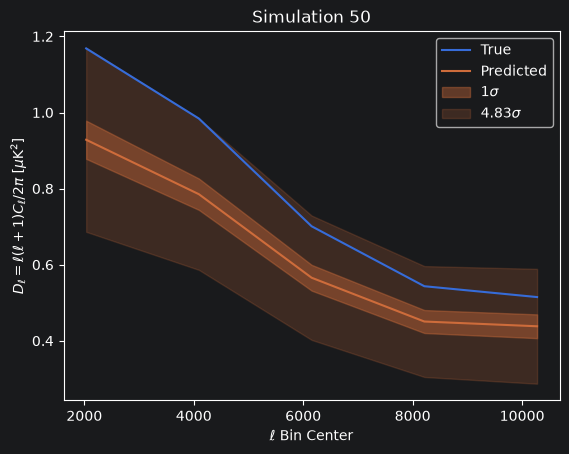

In [14]:
idx = mean_abs_pulls_idx[0]

# Plot true data
plt.plot(ell, np.exp(Y_test[idx]), label="True")
plt.plot(ell, pred_mean[idx], label="Predicted")
plt.fill_between(ell, pred_mean[idx] - pred_std[idx], pred_mean[idx] + pred_std[idx], alpha=0.4, color="C1", label=r"1$\sigma$")
plt.fill_between(ell, pred_mean[idx] - (pred_std[idx] * np.max(abs_pulls[idx])), pred_mean[idx] + (pred_std[idx] *  np.max(abs_pulls[idx])), alpha=0.2, color="C1", label=rf"{np.max(abs_pulls[idx]):.2f}$\sigma$")

plt.title(f"Simulation {idx}")
plt.xlabel(r"$\ell$ Bin Center")
plt.ylabel(r"$D_\ell = \ell(\ell + 1)C_\ell / 2\pi$ [$\mu \mathrm{K}^2$]")
plt.legend()
plt.savefig(fig_path+'most-overconfident', dpi=150, bbox_inches='tight')
plt.show()

# Empirical Coverage
---

In [15]:
one_sigma = np.mean(abs_pulls < 1)
two_sigma = np.mean(abs_pulls < 2)
three_sigma = np.mean(abs_pulls < 3)

print(f"1 sigma: {one_sigma:.2f} \t Gaussian: 0.6826")
print(f"2 sigma: {two_sigma:.2f} \t Gaussian: 0.9545")
print(f"3 sigma: {three_sigma:.2f} \t Gaussian: 0.9973")

1 sigma: 0.66 	 Gaussian: 0.6826
2 sigma: 0.90 	 Gaussian: 0.9545
3 sigma: 0.98 	 Gaussian: 0.9973


# Reliability
---

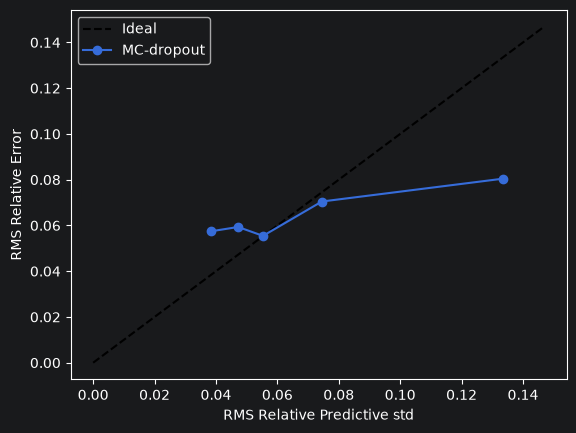

In [16]:
groups = np.array_split(np.argsort(sim_mean_rel_std), 5)
group_std = [np.sqrt(np.mean(rel_std[g] ** 2)) for g in groups]
group_err = [np.sqrt(np.mean(rel_error[g] ** 2)) for g in groups]

lim = 1.1 * max(max(group_std), max(group_err))
plt.plot([0, lim], [0, lim], "k--", label="Ideal")
plt.plot(group_std, group_err, "o-", label="MC-dropout")
plt.xlabel("RMS Relative Predictive std")
plt.ylabel("RMS Relative Error")
plt.legend()
plt.savefig(fig_path + "reliability", dpi=150, bbox_inches="tight")
plt.show()